Is strongly monotone: True
Epoch 0, Loss: 0.358552
Is strongly monotone: True
Epoch 1, Loss: 0.356376
Is strongly monotone: True
Epoch 2, Loss: 0.354225
Is strongly monotone: True
Epoch 3, Loss: 0.352101
Is strongly monotone: True
Epoch 4, Loss: 0.350003
Is strongly monotone: True
Epoch 5, Loss: 0.347933
Is strongly monotone: True
Epoch 6, Loss: 0.345890
Is strongly monotone: True
Epoch 7, Loss: 0.343875
Is strongly monotone: True
Epoch 8, Loss: 0.341889
Is strongly monotone: True
Epoch 9, Loss: 0.339930
Is strongly monotone: True
Epoch 10, Loss: 0.337999
Is strongly monotone: True
Epoch 11, Loss: 0.336097
Is strongly monotone: True
Epoch 12, Loss: 0.334223
Is strongly monotone: True
Epoch 13, Loss: 0.332378
Is strongly monotone: True
Epoch 14, Loss: 0.330561
Is strongly monotone: True
Epoch 15, Loss: 0.328773
Is strongly monotone: True
Epoch 16, Loss: 0.327014
Is strongly monotone: True
Epoch 17, Loss: 0.325285
Is strongly monotone: True
Epoch 18, Loss: 0.323586
Is strongly monotone: 

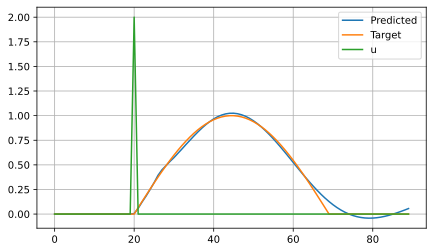

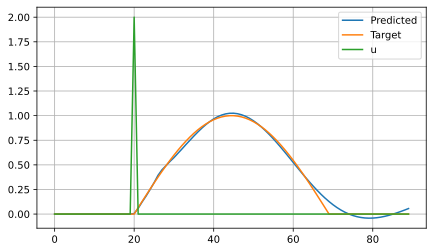

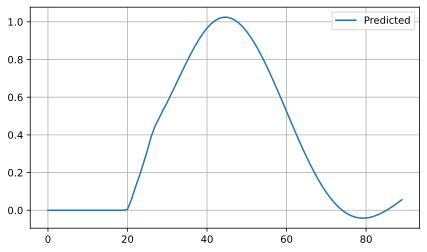

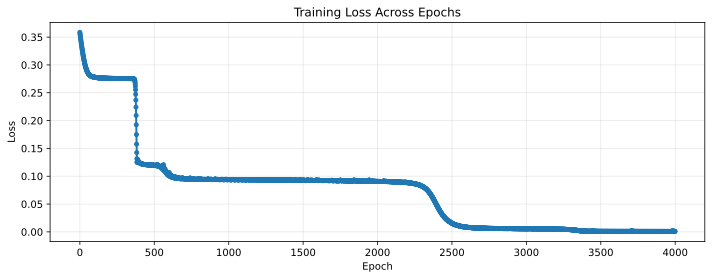

In [23]:
%config InlineBackend.figure_format = 'svg'

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from collections import OrderedDict
from torch.utils.data import DataLoader, TensorDataset

class REN_IQC_gamma(nn.Module):

    def __init__(
        self, dim_in: int, dim_out: int, dim_internal: int,
        dim_nl: int, internal_state_init = None, y_init = None,
        initialization_std: float = 0.5, pos_def_tol: float = 0.001, gammat=None, QR_fun=None, IQC_type='l2_gain',
        Q=None, R=None, S=None, device='cpu'
    ):
        super().__init__()

        self.device = device
        self.dim_in = dim_in
        self.dim_out = dim_out
        self.dim_internal = dim_internal
        self.dim_nl = dim_nl
        self.IQC_type = IQC_type
        self.QR_fun = QR_fun
        self.Q = Q
        self.R = R
        self.S = S
        self.epsilon = pos_def_tol

        # define matrices shapes
        self.X_shape = (2 * dim_internal + dim_nl, 2 * dim_internal + dim_nl)
        self.Y_shape = (dim_internal, dim_internal)
        self.B2_shape = (dim_internal, dim_in)
        self.C2_shape = (dim_out, dim_internal)
        self.D21_shape = (dim_out, dim_nl)
        self.D22_shape = (dim_out, dim_in)
        self.D12_shape = (dim_nl, dim_in)

        #Add learnable parameters for D22
        self.D22_L_shape = (dim_in, dim_in)    # Symmetric positive part
        self.D22_U_shape = (dim_out, dim_in)   # Skew-symmetric part

        self.s = np.max((dim_in, dim_out))
        self.gamma_shape = (1, 1)
        self.gammat = gammat
        self.device = device

        self.training_param_names = ['X', 'Y', 'B2', 'C2', 'D12', 'D22_L', 'D22_U']


        if self.gammat is None:
            self.training_param_names.append('gamma')
        else:
            self.gamma = gammat

        self._init_trainable_params(initialization_std)

        # register buffers
        self.register_buffer('eye_mask_min', torch.eye(min(dim_in, dim_out), device=device))
        self.register_buffer('eye_mask_dim_in', torch.eye(dim_in, device=device))
        self.register_buffer('eye_mask_dim_out', torch.eye(dim_out, device=device))
        self.register_buffer('eye_mask_dim_state', torch.eye(dim_internal, device=device))
        self.register_buffer('eye_mask_H', torch.eye(2 * dim_internal + dim_nl, device=device))
        self.register_buffer('zeros_mask_S', torch.zeros(dim_in, dim_out, device=device))
        self.register_buffer('zeros_mask_Q', torch.zeros(dim_out, dim_out, device=device))
        self.register_buffer('zeros_mask_R', torch.zeros(dim_in, dim_in, device=device))
        self.register_buffer('zeros_mask_so', torch.zeros(dim_internal, dim_out, device=device))
        self.register_buffer('eye_mask_w', torch.eye(dim_nl, device=device))
        self.register_buffer('D21', torch.zeros(dim_out, dim_nl, device=device))# spostato D21 da training_param_names a qui perchè dava problemi (in accordo anche con quello scritto da leo ma diverso da quello scritto nel paper che lo metteva come free parameter )

        batch_size = 1

        if internal_state_init is not None:
            self.x = internal_state_init.reshape(1, 1, dim_internal)
        elif y_init is not None:
            batch_size = y_init.shape[0]
            self.C2 = nn.Parameter(self.C2.data)
            self.x = torch.stack([
                torch.linalg.lstsq(self.C2, y_init[b, 0, :].unsqueeze(1))[0].T
                for b in range(batch_size)
            ], dim=0).unsqueeze(1)
        else:
            self.x = torch.zeros(1, 1, dim_internal)

        self.register_buffer('x_init', self.x.detach().clone())
        y_init_calc = F.linear(self.x_init, self.C2)
        y_init_calc = y_init_calc.view(batch_size, 1, self.dim_out)
        self.register_buffer('y_init', y_init_calc)

        self.to(device)
        self.x = self.x.to(device)


    def _update_model_param(self):
        dim_internal, dim_nl, dim_in, dim_out = self.dim_internal, self.dim_nl, self.dim_in, self.dim_out

        if self.QR_fun is not None:
            self.Q, self.R, self.S = self.QR_fun(self.gamma, dim_in, dim_out, self.IQC_type)
        else:
            # monotone settings
            eps = 1e-4
            self.Q = torch.zeros(self.dim_out, self.dim_out, device=self.device) - eps * torch.eye(self.dim_out, device=self.device)
            self.R = - 2 * self.gamma * torch.eye(self.dim_in, self.dim_in, device=self.device)
            self.S = torch.eye(self.dim_out, self.dim_in, device=self.device)


        #D22 = (gamma + epsilon)I + L'L + (U - U')

        d22_epsilon = 1.0 # margin

        # 1. Base (gamma + margin)
        D_base = (self.gamma + d22_epsilon) * torch.eye(self.dim_out, self.dim_in, device=self.device)

        # 2. Learnablee Positive Part (L'L)
        D_sym = torch.matmul(self.D22_L.T, self.D22_L)

        # 3. Learnable Rotation Part (U - U')
        if self.dim_in == self.dim_out:
            D_skew = self.D22_U - self.D22_U.T
        else:
            D_skew = torch.zeros(self.dim_out, self.dim_in, device=self.device)

        self.D22 = D_base + D_sym + D_skew

        # psi terms
        R_cal = self.R + torch.matmul(self.S, self.D22) + torch.matmul(self.S, self.D22).T + \
                torch.matmul(self.D22.T, torch.matmul(self.Q, self.D22))

        R_cal_inv = torch.inverse(R_cal)

        C2_cal = torch.matmul(torch.matmul(self.D22.T, self.Q) + self.S, self.C2)
        D21_cal = torch.matmul(torch.matmul(self.D22.T, self.Q) + self.S, self.D21) - self.D12.T

        vec_r = torch.cat((C2_cal.T, D21_cal.T, self.B2), dim=0)
        psi_r = torch.matmul(vec_r, torch.matmul(R_cal_inv, vec_r.T))

        vec_q = torch.cat((self.C2.T, self.D21.T, self.zeros_mask_so), dim=0)
        psi_q = torch.matmul(vec_q, torch.matmul(self.Q, vec_q.T))

        H = torch.matmul(self.X.T, self.X) + self.epsilon * self.eye_mask_H + psi_r - psi_q

        h1, h2, h3 = torch.split(H, [dim_internal, dim_nl, dim_internal], dim=0)
        H11, H12, H13 = torch.split(h1, [dim_internal, dim_nl, dim_internal], dim=1)
        H21, H22, _ = torch.split(h2, [dim_internal, dim_nl, dim_internal], dim=1)
        H31, H32, H33 = torch.split(h3, [dim_internal, dim_nl, dim_internal], dim=1)
        self.P_cal = H33
        self.F = H31
        self.B1 = H32
        self.E = 0.5 * (H11 + self.P_cal + self.Y - self.Y.T)
        self.E_inv = self.E.inverse()
        self.Lambda = 0.5 * torch.diag(H22)
        self.D11 = -torch.tril(H22, diagonal=-1)
        self.C1 = -H21


    def forward(self, u_in, t = None, y0=None):
        """
        Forward pass of REN.

        Args:
            u_in (torch.Tensor): Input with the size of (batch_size, 1, self.dim_in).

        Return:
            y_out (torch.Tensor): Output with (batch_size, 1, self.dim_out).
        """
        # update non-trainable model params
        self._update_model_param()

        batch_size = u_in.shape[0]

        w = torch.zeros(batch_size, 1, self.dim_nl, device=u_in.device)

        if t == 0 and y0 is not None:
            # self.x has been already set in reset()
            # w is zero
            # u_in if not zero disrupts initial condition consistency
            pass
        else:
            # update each row of w using Eq. (8) with a lower triangular D11
            for i in range(self.dim_nl): # does the non linear one by one but all together the multiple batches
                #  v is element i of v with dim (batch_size, 1)
                v = F.linear(self.x, self.C1[i, :]) + F.linear(w, self.D11[i, :]) + F.linear(u_in, self.D12[i, :])
                w = w + (self.eye_mask_w[i, :] * torch.tanh(v / self.Lambda[i])).reshape(batch_size, 1, self.dim_nl) # w dim [batch 1 dim_nl]

            # compute next state using Eq. 18
            self.x = F.linear(F.linear(self.x, self.F) + F.linear(w, self.B1) + F.linear(u_in, self.B2), self.E_inv)

        # compute output
        y_out = F.linear(self.x, self.C2) + F.linear(w, self.D21) + F.linear(u_in, self.D22)
        return y_out

    def reset(self, x0=None, y0= None):
        """
        Reset compatibile con ClosedLoopSystem.
        Se x0 è fornito (shape (batch, 1, dim_internal) o (1, 1, dim_internal)),
        lo utilizza come stato; altrimenti usa self.x_init (replicato per batch se necessario).
        """
        batch_size = y0.shape[0]
        if x0 is not None:
            # accetta sia (1,1,dim) sia (batch,1,dim)
            self.x = x0.clone().to(self.device)
        elif y0 is not None:
            self.x = torch.stack([
                torch.linalg.lstsq(self.C2, y0[b, 0, :].unsqueeze(1))[0].T
                for b in range(batch_size)
                ], dim=0).to(self.device)
            self.y_init = y0.detach().clone().to(self.device)
        else:
            # default behaviour: reset to x_init, replicate to batch_size se richiesto
            if batch_size is None:
                self.x = self.x_init.clone().to(self.device)
            else:
                self.x = self.x_init.detach().clone().repeat(batch_size, 1, 1).to(self.device)


    def y0_from_x0(self, x0: torch.Tensor) -> torch.Tensor:
        """
        Given an internal state x0 (batch,1,dim_internal) returns the corresponding y0.
        We assume initial w = 0 and u = 0, so y0 = C2 @ x0 (linear part).
        """
        return F.linear(x0, self.C2)


    def run(self, u_in, x0=None, y0=None):
        """
        Runs the forward pass of REN for a whole input sequence of length horizon.

        Args:
            u_in (torch.Tensor): Input with the size of (batch_size, horizon, self.dim_in).

        Return:
            y_out (torch.Tensor): Output with (batch_size, horizon, self.dim_out).
        """

        self.reset(x0 = x0, y0 = y0)
        # if y0 is not None:
        #     y_log = y0.detach().clone()
        # else:
        #     y_log = self.y_init.detach().clone()

        # non va bene metterl
        
        # batch, horizon, dim_out 
        y_log = torch.empty((u_in.shape[0], 0, self.dim_out), device=u_in.device)

        for t in range(u_in.shape[1]):
            
            
            y_log = torch.cat((y_log, self.forward(u_in[:, t:t + 1, :], t, y0)), 1)
            # print("ciao")
        # note that the last input is not used
        return y_log

    # init trainable params
    def _init_trainable_params(self, initialization_std):
        for training_param_name in self.training_param_names:  # name of one of the training params, e.g., X
            # read the defined shapes of the selected training param, e.g., X_shape
            shape = getattr(self, training_param_name + '_shape')
            # define the selected param (e.g., self.X) as nn.Parameter
            if training_param_name == 'gamma':
                initialization_std = 3
            setattr(self, training_param_name, nn.Parameter((torch.randn(*shape) * initialization_std)))

    # setters and getters
    def get_parameter_shapes(self):
        param_dict = OrderedDict(
            (name, getattr(self, name).shape) for name in self.training_param_names
        )
        return param_dict

    def get_named_parameters(self):
        param_dict = OrderedDict(
            (name, getattr(self, name)) for name in self.training_param_names
        )
        return param_dict

    def __call__(self,u_in, x0=None, y0=None):
        return self.run(u_in, x0, y0)

# --------------------------
# Main Script
# --------------------------

flag_y_ref_pos = True   # True
#if true the y ref is positive, if false is Negative


flag_y_hat_pos = True  # True
#if false the output of the REN is inverted

epochs = 4000

gamma = torch.tensor([0.5])

# --------------------------


y_pos = torch.cat([
    -torch.zeros(20),
    torch.sin(torch.linspace(0, torch.pi, 50)),
    -torch.zeros(20)
])

u = torch.cat([
    torch.zeros(20),
    torch.tensor([2.0]),
    torch.zeros(69)
])

# reshape (T, dim_in)
u = u[:, None].float()        # (T, 1)
y_pos = y_pos[:, None].float()  # (T, 1)
y_neg = -y_pos

T = u.shape[0]

# -------------------------- 2. Define dataset and loader ------------------------------------
# Add batch dimension: (1, T, 1)
dataset_pos = TensorDataset(u[None, :, :], y_pos[None, :, :])
dataset_neg = TensorDataset(u[None, :, :], y_neg[None, :, :])

loader_pos = DataLoader(dataset_pos, batch_size=1, shuffle=False)
loader_neg = DataLoader(dataset_neg, batch_size=1, shuffle=False)

# -------------------------- 3. Define model ---------------------------------------------

y0_0 = torch.zeros(1)[None,:,None]
REN_prova = REN_IQC_gamma(dim_in= 1, dim_out= 1, dim_internal=32, dim_nl= 32, y_init = y0_0, gammat = gamma)

# Loss and optimizer
MSE = nn.MSELoss()
optimizer = torch.optim.Adam(REN_prova.parameters(), lr=0.001)

# -------------------------- 4. Training loop ---------------------------------------------

train_losses = []

if flag_y_ref_pos:
    loader = loader_pos
else:
    loader = loader_neg

for epoch in range(epochs):
    REN_prova.train()
    epoch_loss = 0.0
    for u_batch, y_batch in loader:
        optimizer.zero_grad()
        # REN_prova.reset(y0 = y_batch[:,:1,:1])
        y_hat = REN_prova(u_batch, y0 = y_batch[:,:1,:1])   # builds graph only for this sequence

        # 1. Calcola (u - v)^2 elemento per elemento
        squared_diff = u_batch**2 

        # 2. Somma su tutte le dimensioni della sequenza e delle feature 
        #    Risultato è ||u - v||_T^2
        norm_sq_u = torch.sum(squared_diff, dim=(1, 2), keepdim=True) # -> 4
        
        # y_hat*u_batch -> tutto a 0
        scalar_prod_y_u = torch.sum(y_hat*u_batch, dim=(1, 2), keepdim=True) #-> 0
        
        is_strongly_monotone = scalar_prod_y_u >= gamma * norm_sq_u  # 0 >= 40
        
        if is_strongly_monotone[0,0,0].item() is False:
            print("Warning: The model is not strongly monotone for the current batch.")
        
        print(f"Is strongly monotone: {is_strongly_monotone[0,0,0]}")
        # conto bene sarebbe da iterare su ogni subset di tempo partendo da 0
        # c'è comunque qualcosa che non va dato che non lo è, forse dovuto a D22? dovrebbe andare su appena ha lìimpulso per soddisfare questa condizione
      
        if flag_y_hat_pos == False:
            y_hat = -y_hat

        loss = MSE(y_hat, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss)

    print(f"Epoch {epoch}, Loss: {epoch_loss:.6f}")

    if epoch == epochs-1:

        plt.figure(figsize=(7,4))
        plt.plot(y_hat[0,:,0].detach().numpy(), label='Predicted')
        plt.plot(y_batch[0,:,0].detach().numpy(), label='Target')
        plt.plot(u_batch[0,:,0].detach().numpy(), label='u')
        plt.grid()
        plt.legend()
        plt.show()



plt.figure(figsize=(7,4))
plt.plot(y_hat[0,:,0].detach().numpy(), label='Predicted')
plt.plot(y_batch[0,:,0].detach().numpy(), label='Target')
plt.plot(u_batch[0,:,0].detach().numpy(), label='u')
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(y_hat[0,:,0].detach().numpy(), label='Predicted')
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(range(len(train_losses)), train_losses, marker='o', linewidth=2, markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Across Epochs')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

